In [1]:
#导入包体
#需要torch库
# mlp模型的建立（torch.nn）
# 数据集的获取和拆分（torch.utils.data和torchvision）
# 画图（matplotlib.pyplot）
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

#检查设备状态
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"using device:{device}")

using device:mps


In [2]:
#数据的导入，Tensor即换容器
# datasets.数据集名(root下载路径, train数据包自带的测试集拆分, download是否下载, transform图片转化为数据)即题库
#dataloader.数据集名(数据集, batch_size每次训练的样本数, shuffle是否打乱数据, num_workers加载数据的线程数)即随机发题
trainset=datasets.MNIST(root="./data",train=True,download=True,transform=transforms.ToTensor())
trainloader=DataLoader(trainset,batch_size=64,shuffle=True,num_workers=0)
testset=datasets.MNIST(root="./data",train=False,download=True,transform=transforms.ToTensor())
testloader=DataLoader(testset,batch_size=64,shuffle=False,num_workers=0)
print(f"trainset:{len(trainset)},testset:{len(testset)}")

trainset:60000,testset:10000


In [3]:
#MLP模型的建立
# class 模型名(nn.Module):        # ① 继承：拿到"模型"身份
#     def __init__(self):         # ② 声明层：我有哪些零件
#         super().__init__()
#         self.xxx = nn.XXX(...)
#     def forward(self, x):       # ③ 编排：零件怎么接
#         x = ...
#         return x

# 定义向前传播函数，核心就是：
# 一 forward = 按 __init__ 的顺序“点名”零件。​
# 你在 __init__ 里定义了什么，forward 里就调用什么；定义了没用上的层等于白买。
# 二 跟着形状走
# 每调一层，问一句“进去什么形状、出来什么形状”，对上了就不会错。调试时可以用 print 强制检查：
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten=nn.Flatten()  # 将输入展平为一维向量
        self.linear_relu_stack=nn.Sequential(
            nn.Linear(28*28,256),  # 输入层到隐藏层1
            nn.ReLU(),      
            nn.Linear(256,10)
        )
    def forward(self,x):
        x=self.flatten(x)
        x=self.linear_relu_stack(x)
        return x

#查看模型的零件
m=MLP()
print(m)       

MLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=10, bias=True)
  )
)


In [4]:
#损失函数和优化器
lossfn=nn.CrossEntropyLoss()  # 交叉熵损失函数
optimizer=torch.optim.Adam(m.parameters(), lr=1e-3)  # Adam优化器

In [25]:
#训练模型
# 外循环 epoch（整本题库过几遍）
#   └─ 内循环 batch（每次取 64 张）
#        └─ 四件套（清梯度→前向→打分→反传→改权重）
# for epoch in range(EPOCHS):
#     for X, y in loader:            # 占位符①：任何 DataLoader
#         ...
#         scores = model(X)          # 占位符②：任何模型
#         loss = loss_fn(scores, y)  # 占位符③：配对的损失函数
#         ...
#         optimizer.step()
m = m.to(device)
m.train()  # 训练模式
Epoch=1

print("开始训练")
# X, y = next(iter(trainloader))
# print(X.shape)    # torch.Size([64, 1, 28, 28])  ← 64 张图
# print(y.shape)    # torch.Size([64])             ← 64 个答案
# print(y[:8])      # 切片，tensor([7, 2, 1, 0, 4, 1, 4, 9])  ← 长这样

for epoch in range(Epoch):
    total_loss = 0.0

    for X, y in trainloader:              # ← 名字跟你格2的 DataLoader 对齐
        X, y = X.to(device), y.to(device)  # 数据搬上 GPU

        optimizer.zero_grad()              # ① 清掉上一批的旧梯度
        scores = m(X)                      # ② 前向：[64,10] 的得分
        loss = lossfn(scores, y)          # ③ 打分：一个数字
        loss.backward()                    # ④ 算出全部梯度（不用你管怎么算的）
        optimizer.step()                   # ⑤ 按梯度微调权重，更新参数

        total_loss += loss.item() * len(y) # 累加这批的 loss（乘回样本数才能公平平均）.item() 是 Tensor 的一个方法，作用只有一件事：把只装了一个数字的 Tensor，变成普通的 Python 数字
        avg = total_loss / len(trainset)    # 一个epoch跑完后：总分 ÷ 总张数55000
print(f"epoch {epoch+1}/{Epoch}  平均loss: {avg:.4f}")


开始训练
epoch 1/1  平均loss: 0.1270


In [ ]:
#模型测试评估
# model.eval()                      # ① 切考试模式
# with torch.no_grad():             # ② 关梯度（整个测试包在这一句里）
#     for X, y in loader:           # ③ 循环取批
#         X, y = X.to(device), y.to(device)
#         scores = model(X)         # ④ 只前向，不 backward、不 step
#         correct += (scores.argmax(1) == y).sum().item()   # ⑤ 统计对错（分类任务专属）

m.eval()  # 测试模式
correct = 0
with torch.no_grad():             # 考试不算梯度
    for X, y in testloader:       # ← 你格2里 train=False 那个 loader
        X, y = X.to(device), y.to(device)
        scores = m(X)
        correct += (scores.argmax(1) == y).sum().item()

print(f"测试集准确率: {correct / 10000 * 100:.1f}%")   # 预期 0.97 左右

测试集准确率: 97.1%


In [ ]:
#训练5次
Epoch=5
print("开始训练")
for epoch in range(Epoch):
    total_loss = 0.0

    for X, y in trainloader:              # ← 名字跟你格2的 DataLoader 对齐
        X, y = X.to(device), y.to(device)  # 数据搬上 GPU
        optimizer.zero_grad()              # ① 清掉上一批的旧梯度
        scores = m(X)                      # ② 前向：[64,10] 的得分
        loss = lossfn(scores, y)          # ③ 打分：一个数字
        loss.backward()                    # ④ 算出全部梯度（不用你管怎么算的）
        optimizer.step()                   # ⑤ 按梯度微调权重，更新参数

        total_loss += loss.item() * len(y) # 累加这批的 loss（乘回样本数才能公平平均）.item() 是 Tensor 的一个方法，作用只有一件事：把只装了一个数字的 Tensor，变成普通的 Python 数字
        avg = total_loss / len(trainset)    # 一个epoch跑完后：总分 ÷ 总张数55000
print(f"epoch {epoch+1}/{Epoch}  平均loss: {avg:.4f}")

m.eval()  # 测试模式
correct = 0
with torch.no_grad():             # 考试不算梯度
    for X, y in testloader:       # ← 你格2里 train=False 那个 loader
        X, y = X.to(device), y.to(device)
        scores = m(X)
        correct += (scores.argmax(1) == y).sum().item()

print(f"测试集准确率: {correct / 10000 * 100:.1f}%")   # 预期 0.97 左右


开始训练
epoch 5/5  平均loss: 0.0278
测试集准确率: 98.1%


In [5]:
#loss作图
# 画 Loss 曲线就是把“模型学习的过程”变成一张图——横轴是 epoch（第几轮），纵轴是 loss（错得多离谱）。它是训练的“体检报告”，也是题目 README 的硬性要求。
m = MLP()
m = m.to(device)
m.train()  # 训练模式
Epoch=5
train_losses = []                  # ← 新增：记录每轮的 loss
for epoch in range(Epoch):
    total_loss = 0.0
    for X, y in trainloader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        scores = m(X)
        loss = lossfn(scores, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(y)
    avg = total_loss / len(trainset)
    train_losses.append(avg)       # ← 新增：这一轮的平均loss存起来
    print(f"epoch {epoch+1}/{Epoch}  平均loss: {avg:.4f}")



epoch 1/5  平均loss: 2.2979
epoch 2/5  平均loss: 2.2979
epoch 3/5  平均loss: 2.2979
epoch 4/5  平均loss: 2.2979
epoch 5/5  平均loss: 2.2979


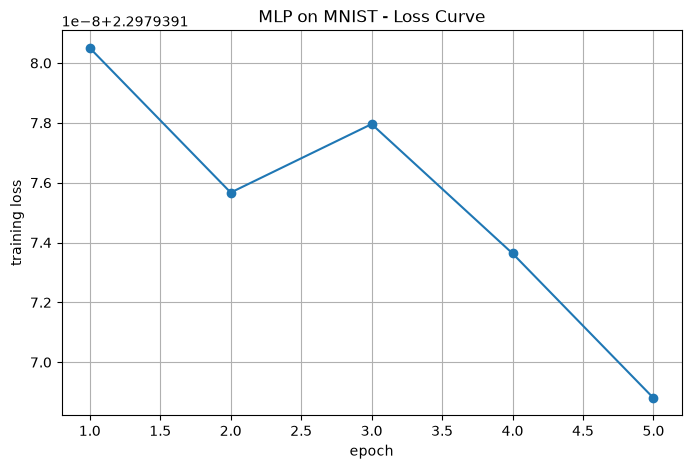

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(range(1, Epoch + 1), train_losses, marker='o')
plt.xlabel("epoch")                # 横轴：第几轮
plt.ylabel("training loss")        # 纵轴：平均loss
plt.title("MLP on MNIST - Loss Curve")
plt.grid(True)
plt.savefig("loss_curve.png", dpi=150)   # 存进项目文件夹（README要用）
plt.show()